# Proyecto Data Science : Hacking The Human Body
En esta segunda parte se elige y se prueba los modelos más aptos para el reconocimiento de tejidos. Basado en la investigación previa, emplearemos diferentes métricas de rendimiento, exactitud y precisión para determinar cuál provee los mejores resultados.

## Investigación de los modelos más aptos

## CNN
Las CNN (Convolutionary Neural Networks), Redes Neuronales Convolucionares en español, son un conjunto de redes cuya especialización es el reconocimiento de imágenes. Usalmente utilizadas para la clasificación o corrección de imágenes, estas poseen fuertes capacidades para lo que nosotros buscamos con este proyecto. Identificar diferentes tipos de tejidos corporales correctamente. 
Ahora bien, los modelos CNN como previamente dicho son buenos para identificar correctamente imágenes o son efectivos para su clasificación. Sin embargo, en este problema, queremos identificar los FTU que existen dentro de las imágenes e identificar cada uno respecto a sus tejidos. Por lo tanto, necesitaremos más ayuda que meramente una CNN para lograr identificar la imagen si no también identificar sus características internas. 

### ResNet con U-Net
La ResNet o Residual Network es un tipo de CNN que se enfoca en solucionar algunos problemas que padecen las redes neuronales convolucionarias normales. Esta red mejora el gradiente desvaneciente (cuando el gradiente se hace muy chico y retrasa el aprendizaje) mediante la omisión de conexiones entre ciertas capas que le permite evitar que eso ocurra durante el backpropagation. Sin embargo, como necesitamos también detectar los FTU, utilizamos U-Net junto con ResNet, logramos detectar features con ResNet y como encoder y U-Net como encoder para regresar a resolución completa.



### Referencias 
- Leonardo Reginato (14 October 2024) [A Practical Comparison Between CNN and ResNet Architectures: A Focus on Attention Mechanisms](https://medium.com/@leonardofonseca.r/a-practical-comparison-between-cnn-and-resnet-architectures-a-focus-on-attention-mechanisms-cee7ec8eca55)
- Yakub A. Bayhaqi, Arsham Hamidi, Ferda Canbaz, Alexander A. Navarini, Philippe C. Cattin, and Azhar Zam (2021) [Deep learning models comparison for tissue classification using optical coherence tomography images: toward smart laser osteotomy ](https://opg.optica.org/osac/fulltext.cfm?uri=osac-4-9-2510)
- Jie Li, Weiwei Goh, Noor Zaman Jhanjhi (16 October 2025) [A lightweight CNN for colon cancer tissue classification and visualization](https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.2025.1659010/full)
- Siddhesh Bangar (28 June 2022) [VGG-Net Architecture Explained](https://medium.com/@siddheshb008/vgg-net-architecture-explained-71179310050f)

In [1]:
# verify CUDA and PyTorch 
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


2.9.0+cu128
CUDA available: True
Device: NVIDIA GeForce RTX 4060


### Binary masks
Se le aplica máscaras binarias a los polígonos dados en train_annotations para las coordenadas.

In [8]:
import json, os, cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
import glob
from pathlib import Path
import matplotlib.pyplot as plt



In [5]:

def polygons_to_masks(path: str | Path, image_shape):
    with open(path, 'r') as f:
        data = json.load(f)

    mask = np.zeros(image_shape[:2], dtype=np.uint8)
    for polygon in data:
        pts = np.array(polygon, dtype=np.int32)
        cv2.fillPoly(mask, [pts], color=1)
    return mask


In [ ]:
IMAGE_DIR = Path("data/train_data")
ANNOT_DIR = Path("data/train_annotations")
OUTPUT_IMG_DIR = Path("data/processed/images")
OUTPUT_MASK_DIR = Path("data/processed/masks")
OUTPUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_MASK_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = (512, 512)  # (width, height)

In [7]:
for image_path in tqdm(sorted(IMAGE_DIR.glob("*.tiff"))):
    name = image_path.stem
    json_path = ANNOT_DIR / f"{name}.json"
    if not json_path.exists():
        continue # skip iteration
    
    # image
    img = np.array(Image.open(image_path).convert("RGB"))
    h,w = img.shape[:2]
    mask = polygons_to_masks(json_path, (h, w, 3))

    # mask
    img_resized  = cv2.resize(img,  TARGET_SIZE, interpolation=cv2.INTER_AREA)
    mask_resized = cv2.resize(mask, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)

    # save
    cv2.imwrite(str(OUTPUT_IMG_DIR / f"{name}.png"), cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_MASK_DIR / f"{name}_mask.png"), mask_resized * 255)

100%|██████████| 351/351 [00:26<00:00, 13.44it/s]


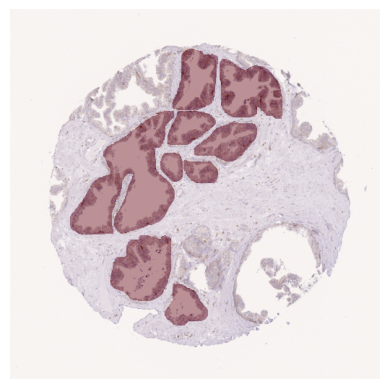

In [ ]:
# display image with mask to make sure it was done properly 
img  = cv2.imread(str(next(OUTPUT_IMG_DIR.glob("*.png"))))
mask = cv2.imread(str(next(OUTPUT_MASK_DIR.glob("*.png"))), 0)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.imshow(mask, cmap='Reds', alpha=0.4)
plt.axis('off')
plt.show()

In [ ]:
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
import random


class FtuSegDataset(Dataset):

    def __init__(self, img_dir: Path, mask_dir: Path, augment: bool=False) -> None:
        self.img_dir: Path = Path(img_dir)
        self.mask_dir: Path = Path(mask_dir)
        self.augment: bool = augment
        self.images: list[Path] = sorted([p for p in self.img_dir.glob("*.png")])

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        name = img_path.stem
        mask_path = self.mask_dir / f"{name}_mask.png"
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L") 

        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()  # [1,H,W], {0,1}

        # simple paired augmentations
        if self.augment:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() < 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

        # normalize 
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        image = (image - mean) / std

        return image, mask

In [16]:
# create train / val test split
from torch.utils.data import DataLoader, random_split

root = Path("data/processed")
img_dir = root / "images"
mask_dir = root / "masks"


full_dataset = FtuSegDataset(img_dir, mask_dir, augment=True)

val_fraction: float = 0.2
val_size = int(len(full_dataset) * val_fraction)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# no random augment on val
val_dataset.dataset.augment = False

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

### ResNet & U-Net

In [13]:
import torch.nn as nn
import segmentation_models_pytorch as smp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)


c:\Users\lpmon\Documents\GitHub\Hacking-the-Human-Body\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\lpmon\Documents\GitHub\Hacking-the-Human-Body\venv\Lib\site-packages\huggingface_hub\file_download.py:121: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lpmon\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run P

In [14]:
# calculate loss 
bce = nn.BCEWithLogitsLoss()

# utilize Dice coefficient to measure 
# 2 * |X ∩ Y| / |X| + |Y|
def dice_loss(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2,3))
    den = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + eps
    return 1 - (num / den).mean()

def combo_loss(logits, targets, alpha=0.5):
    return alpha * bce(logits, targets) + (1 - alpha) * dice_loss(logits, targets)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
# run epochs to train

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images, masks in tqdm(loader, leave=False):
        images = images.to(device)
        masks = masks.to(device)

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = combo_loss(logits, masks)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # metrics
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            # Dice for monitoring
            inter = (preds * masks).sum(dim=(2,3))
            union = preds.sum(dim=(2,3)) + masks.sum(dim=(2,3))
            dice = ((2 * inter + 1e-7) / (union + 1e-7)).mean()

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_dice += dice.item() * bs

    n = len(loader.dataset)
    return total_loss / n, total_dice / n

NUM_EPOCHS = 10 # TODO increate the number of epochs, check if that makes a better result

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_dice = run_epoch(train_loader, train=True)
    val_loss, val_dice = run_epoch(val_loader,   train=False)
    
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f}  train_dice={train_dice:.4f} | val_loss={val_loss:.4f}  val_dice={val_dice:.4f}")


Epoch 01 | train_loss=0.7411  train_dice=0.2842 | val_loss=0.6161  val_dice=0.3989


Epoch 02 | train_loss=0.5793  train_dice=0.4608 | val_loss=0.5481  val_dice=0.5249


Epoch 03 | train_loss=0.5035  train_dice=0.5647 | val_loss=0.4693  val_dice=0.5749


Epoch 04 | train_loss=0.4507  train_dice=0.6284 | val_loss=0.4218  val_dice=0.6309


Epoch 05 | train_loss=0.4091  train_dice=0.6580 | val_loss=0.3943  val_dice=0.6691


Epoch 06 | train_loss=0.3610  train_dice=0.6910 | val_loss=0.3603  val_dice=0.6686


Epoch 07 | train_loss=0.3272  train_dice=0.7142 | val_loss=0.3681  val_dice=0.6399


Epoch 08 | train_loss=0.2837  train_dice=0.7557 | val_loss=0.3244  val_dice=0.6826


Epoch 09 | train_loss=0.2538  train_dice=0.7782 | val_loss=0.3038  val_dice=0.6887


Epoch 10 | train_loss=0.2360  train_dice=0.7828 | val_loss=0.2792  val_dice=0.6927


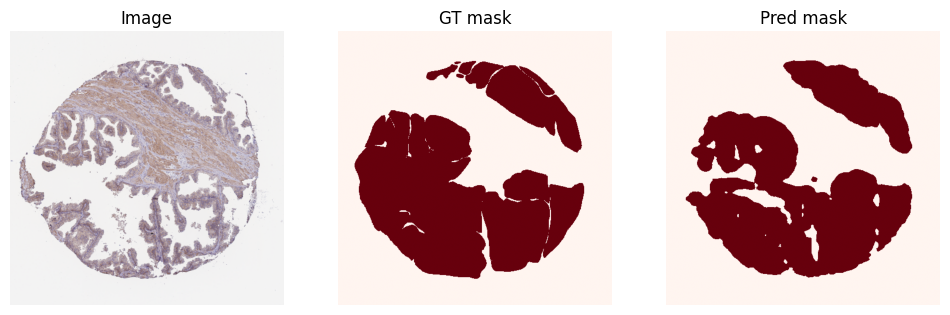

In [ ]:
# evaluate results
model.eval()
images, masks = next(iter(val_loader))
images = images.to(device)
with torch.no_grad():
    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

# visualize first sample
i = 0
img_np = images[i].cpu()

# unnormalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_np = (img_np * std + mean).clamp(0,1).permute(1,2,0).numpy()

gt = masks[i,0].cpu().numpy()
pr = preds[i,0].cpu().numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img_np); plt.axis("off")
plt.subplot(1,3,2); plt.title("GT mask"); plt.imshow(gt, cmap="Reds"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Pred mask"); plt.imshow(pr, cmap="Reds"); plt.axis("off")
plt.show()
